# DATASCI 503, Group Work 9: PCA and Clustering

**Instructions:** During lab section, and afterward as necessary, you will collaborate in two-person teams (assigned by the GSI) to complete the problems that are interspersed below. The GSI will help individual teams encountering difficulty, make announcements addressing common issues, and help ensure progress for all teams. During lab, feel free to flag down your GSI to ask questions at any point!

In [47]:
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: pip in c:\Users\Bryant Willoughby\AppData\Local\Programs\Python\Python313\Lib\site-packages (26.0.1)



In [48]:
# %pip install plotly
# %pip install scanpy

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.figure_factory as ff
import scanpy as sc
import seaborn as sns
from sklearn import datasets
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, pairwise_distances

import os

if os.path.isdir("fixtures"):
    !cp -n fixtures/* .

## PCA

- PCA replaces the original $p$ variables with $d<p$ linear combinations of the original variables that are a "good representation" of the data.

- Mathematical formulation of PCA: The problem is to find the $k$ th new variable $Z_k$ which is a linear combination of the original variables $X_1, X_2, \cdots, X_p$ (i.e. $\left.Z_k=\sum_{j=1}^p w_{k j} X_j\right)$ such that it maximizes
  $$
  w_k^T \Sigma w_k \\
  \text { subject to } w_k^T w_k=1, w_k^T w_{k^{\prime}}=0, k^{\prime}<k
  $$

  The solution to the above problem is given by the eigendecomposition of $\Sigma$: \\
  $\Sigma=W \Lambda W^T$, where $W$ is a  $p \times p$ matrix of (column) eigenvectors and $\Lambda$ is a $p \times p$ diagonal matrix of eigenvalues.

- PCA in practice: Let $X_{n \times p}$ now be the $n \times p$ data matrix (centered). Each data point is represented by a row.
    - Compute the sample covariance matrix $\hat{\Sigma}= \frac{1}{n-1}X^{\top} X$
    - Vectors $w_k$ 's are the eigenvectors of $\hat{\Sigma}$ and are called **PC directions**. The coordinates $w_{k j}$ are called **(factor) loadings**.
    - Vectors $z_k=X w_k(k=1, \ldots, d)$ are called the **principal components** of $X$ and are projections of the data onto the PC directions. Components of $X w_k$ are also called scores.
    - $\operatorname{var}\left(X w_k\right)=\lambda_k$, the eigenvalues of $\hat{\Sigma} ; \lambda_1 \geq \lambda_2 \geq \ldots \lambda_p \geq 0$.
    
    
- How to pick the number of PCs?
  - For visualization, can only use 2 or 3
  - Can choose $d$ to explain certain percent of variation: pick first $d$ so that $\frac{\sum_{k=1}^d \lambda_k}{\sum_{k=1}^p \lambda_k} \geq (1-\alpha)$
    for some pre-specified small alpha (e.g. 0.1)
  - Scree plot: plot $\lambda_k$ or $\sqrt{\lambda_k}$ against $k$ and look for an 'elbow'

Now we use the crab dataset for a PCA practice.

In [50]:
crabs = pd.read_csv("crabs.csv", index_col=0)
crabs.index = crabs["index"]
crabs.drop(columns=["index"], inplace=True)

In [51]:
crabs.shape

(200, 7)

``sp``: species - "B" or "O" for blue or orange.

``sex``: male or female

``index``: index 1:50 within each of the four groups.

``FL``: frontal lobe size (mm).

``RW``: rear width (mm).

``CL``: carapace length (mm).

``CW``: carapace width (mm).

``BD``: body depth (mm).

In [52]:
crabs.head()

,sp,sex,FL,RW,CL,CW,BD
index,,,,,,,
1,B,M,8.1,6.7,16.1,19.0,7.0
2,B,M,8.8,7.7,18.1,20.8,7.4
3,B,M,9.2,7.8,19.0,22.4,7.7
4,B,M,9.6,7.9,20.1,23.1,8.2
5,B,M,9.8,8.0,20.3,23.0,8.2


In [53]:
crabs.describe()

,FL,RW,CL,CW,BD
count,200.000000,200.00000,200.000000,200.000000,200.000000
mean,15.583000,12.73850,32.105500,36.414500,14.030500
std,3.495325,2.57334,7.118983,7.871955,3.424772
min,7.200000,6.50000,14.700000,17.100000,6.100000
25%,12.900000,11.00000,27.275000,31.500000,11.400000
50%,15.550000,12.80000,32.100000,36.800000,13.900000
75%,18.050000,14.30000,37.225000,42.000000,16.600000
max,23.100000,20.20000,47.600000,54.600000,21.600000


In [54]:
crabs.describe(include="object")

,sp,sex
count,200,200
unique,2,2
top,B,M
freq,100,100


Now, we use the 4 numerical (continuous) variables to perform PCA.

In [55]:
X = crabs.iloc[:, 3:]
X.head()

,RW,CL,CW,BD
index,,,,
1,6.7,16.1,19.0,7.0
2,7.7,18.1,20.8,7.4
3,7.8,19.0,22.4,7.7
4,7.9,20.1,23.1,8.2
5,8.0,20.3,23.0,8.2


In [56]:
pca = PCA(svd_solver="full")
pca.fit(X)

PCA(svd_solver='full')

In [57]:
# By default, it is min(n_features, n_samples)
pca.n_components_

4

We can get the amount of variance explained by each of the selected components by using the attribute ``explained_variance_``. Note that it corresponds to the eigenvalue $\lambda_k$.

In [58]:
pca.explained_variance_

array([1.28998080e+02, 1.23209821e+00, 6.89092074e-01, 7.94701148e-02])

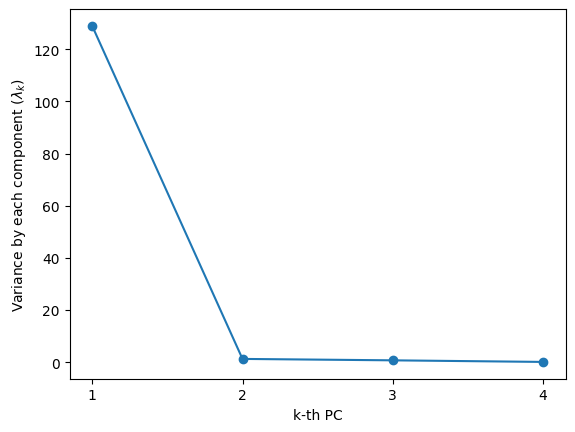

In [59]:
plt.plot(range(1, pca.n_components_ + 1), pca.explained_variance_, "-o")
plt.xticks(range(1, pca.n_components_ + 1))
plt.xlabel("k-th PC")
plt.ylabel(r"Variance by each component ($\lambda_k$) ")
plt.show()

The percentage of variance explained by each of the selected components is calculated as follows:

In [60]:
# pca?

In [61]:
np.round(pca.explained_variance_ratio_, 3)

array([0.985, 0.009, 0.005, 0.001])

The transformed data (the scores) can be calculated as follows:

In [62]:
Z = pca.transform(X)
print(Z.shape)

(200, 4)


Now we try to visualize the first two dimensions based on the PCA results.

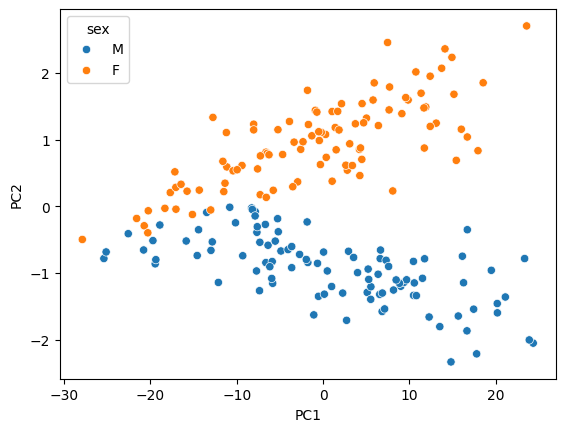

In [63]:
sns.scatterplot(x=Z[:, 0], y=Z[:, 1], hue=crabs["sex"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

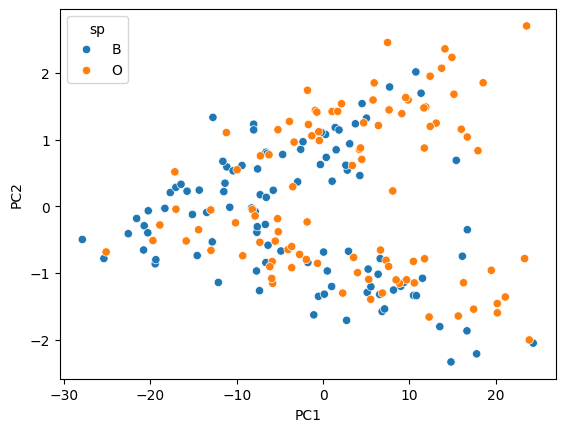

In [64]:
sns.scatterplot(x=Z[:, 0], y=Z[:, 1], hue=crabs["sp"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

---

**Problem 1:** Synthetic Data Generation

Generate some data of rank 3. Create 250 observations of features $z \sim \text{MVN}([5, 3, 1], I)$. Then, create a low-rank data matrix $X$ such that $X = ZL + \epsilon$, where $L$ is a 3x50 matrix of standard normal values and $\epsilon \sim N(0, 0.25)$.

Store your results in the following variables:
- `latent_samples`: the 250x3 matrix of multivariate normal samples (Z)
- `projection_matrix`: the 3x50 matrix of standard normal values (L)
- `data_matrix`: the final 250x50 low-rank data matrix with noise (X)

Use `np.random.seed(503)` to set the seed before generating your data.

In [65]:
# np.random.normal?

In [66]:
mean = [5, 3, 1]
cov = np.identity(3)

np.random.seed(503)

latent_samples = np.random.multivariate_normal(mean, cov, size=250)
projection_matrix = np.random.randn(3, 50)
noise = np.random.normal(loc=0, scale=0.25, size=(250, 50))

data_matrix = latent_samples @ projection_matrix + noise

In [67]:
# Test assertions
assert latent_samples.shape == (250, 3), f"Expected latent_samples shape (250, 3), got {latent_samples.shape}"
assert projection_matrix.shape == (3, 50), f"Expected projection_matrix shape (3, 50), got {projection_matrix.shape}"
assert data_matrix.shape == (250, 50), f"Expected data_matrix shape (250, 50), got {data_matrix.shape}"
print("All tests passed!")

All tests passed!


---

**Problem 2:** Recovering Principal Components

Run PCA with 10 components on `data_matrix`. Assess the total variance explained by the principal components. Based on this assessment, decide how many PCs to use for downstream clustering.

Create a plot of the cumulative sum of variance explained by PCA.

Store your results in the following variables:
- `pca_model`: the fitted PCA model
- `explained_variance_cumsum`: a NumPy array of cumulative variance explained ratios
- `n_pcs_chosen`: an integer — the number of PCs needed to explain at least 90% of the variance

In [68]:
# pca_model.explained_variance_ratio_?

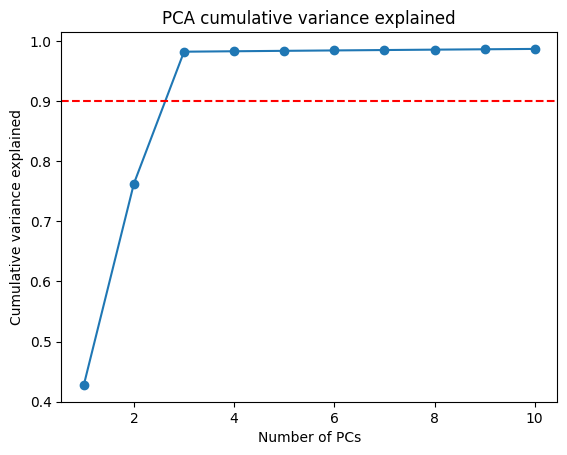

In [69]:
pca_model = PCA(n_components=10, random_state=503)
pca_model.fit(data_matrix)

explained_variance_cumsum = np.cumsum(pca_model.explained_variance_ratio_)
# The number of PCs needed to explain at least 90% of the variance
n_pcs_chosen = int(np.searchsorted(explained_variance_cumsum, 0.9) + 1)

plt.plot(range(1, 11), explained_variance_cumsum, marker="o")
plt.axhline(0.9, color="red", linestyle="--")
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative variance explained")
plt.title("PCA cumulative variance explained")
plt.show()

In [70]:
# Test assertions
assert pca_model is not None, "PCA model should be created"
assert len(explained_variance_cumsum) == 10, "Should have 10 cumulative variance values"
assert explained_variance_cumsum[-1] <= 1.0, "Cumulative variance should not exceed 1.0"
assert isinstance(n_pcs_chosen, int), "n_pcs_chosen should be an integer"
print("All tests passed!")

All tests passed!


## Clustering

A dendrogram is a diagram representing a tree. The figure factory called create_dendrogram performs hierarchical clustering on data and represents the resulting tree. Values on the tree depth axis correspond to distances between clusters.

Dendrogram plots are commonly used in computational biology to show the clustering of genes or samples, sometimes in the margin of heatmaps.

In [71]:
np.random.seed(1)

dendrogram_data = np.random.rand(15, 12)  # 15 samples, with 12 dimensions each
fig = ff.create_dendrogram(dendrogram_data)
fig.update_layout(width=800, height=500)
fig.show()

We can also set up a height or threshold manually.

In [72]:
dendrogram_data = np.random.rand(15, 10)  # 15 samples, with 10 dimensions each
fig = ff.create_dendrogram(dendrogram_data, color_threshold=1.5)
fig.update_layout(width=800, height=500)
fig.show()

Now we practice another clustering method: K-means clustering. We work on a synthetic baby data.

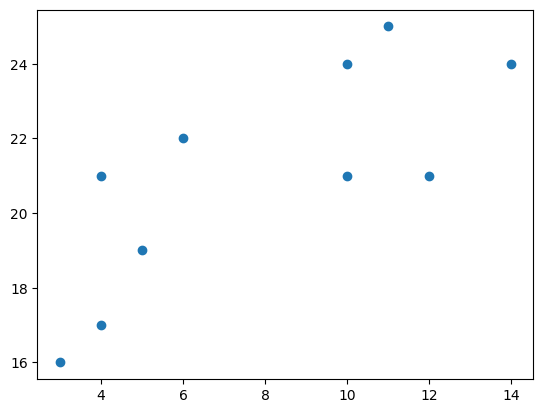

In [73]:
x = [4, 5, 10, 4, 3, 11, 14, 6, 10, 12]
y = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]

plt.scatter(x, y)
plt.show()

"Inertia," also known as within-cluster sum of squares (WSS), measures squared distances between points and the centroid of their cluster.  It is equal to one-half the within-cluster variation (i.e., sum of squared distance between all pairs of points in the same cluster, divided by size of cluster, summed over all clusters).

Now we utilize the elbow method to visualize the inertia for different values of K:

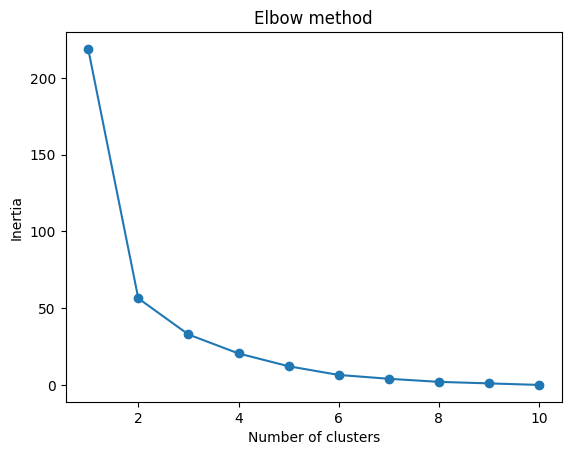

In [74]:
data = list(zip(x, y))
inertias = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1, 11), inertias, marker="o")
plt.title("Elbow method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

The elbow method shows that 2 is a good value for K, so we retrain and visualize the result using K=2.

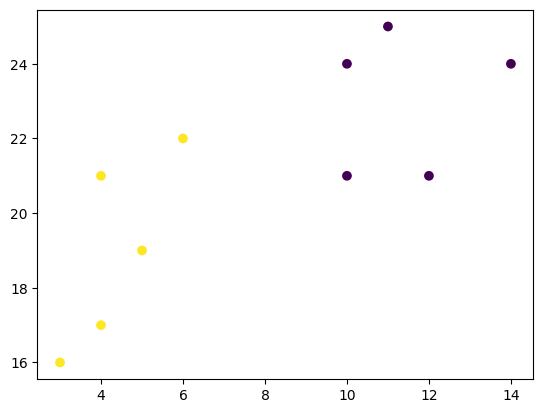

In [75]:
kmeans = KMeans(n_clusters=2)
kmeans.fit(data)

plt.scatter(x, y, c=kmeans.labels_)
plt.show()

### Clustering Evaluation Metrics: TSS, WSS, and BSS

When evaluating clustering quality, we use several metrics based on sum of squares:

**Notation:**
- Let $x_j\in\mathbb{R}^d$, for $j=1,\ldots,n$, be data points.
- Let $C_1,\ldots,C_K$ be a partition of the indices $1,\ldots,n$ into disjoint clusters.
- For cluster $C_k$ with size $n_k=|C_k|$, define the cluster mean: $\bar{x}_{(k)} = \frac{1}{n_k}\sum_{j\in C_k} x_j$
- Define the grand mean: $\bar{x} = \frac{1}{n} \sum_{j=1}^n x_j$

**Metrics:**

- **Total Sum of Squares (TSS)**: measures spread of points from the grand mean
$$\mathrm{TSS} = \sum_{j=1}^n \|x_j - \bar{x}\|^2$$

- **Within-Cluster Sum of Squares (WSS)**: measures spread of points around their respective cluster means
$$\mathrm{WSS} = \sum_{k=1}^K \sum_{j\in C_k} \|x_j - \bar{x}_{(k)}\|^2$$

- **Between-Cluster Sum of Squares (BSS)**: measures spread of cluster means around the grand mean
$$\mathrm{BSS} = \sum_{k=1}^K n_k \|\bar{x}_{(k)} - \bar{x}\|^2$$

These satisfy the identity: $\mathrm{TSS} = \mathrm{WSS} + \mathrm{BSS}$

**Key insight:** TSS is fixed for a dataset, while WSS and BSS depend on cluster assignment. Good clustering has low WSS (tight clusters) and high BSS (well-separated centers).

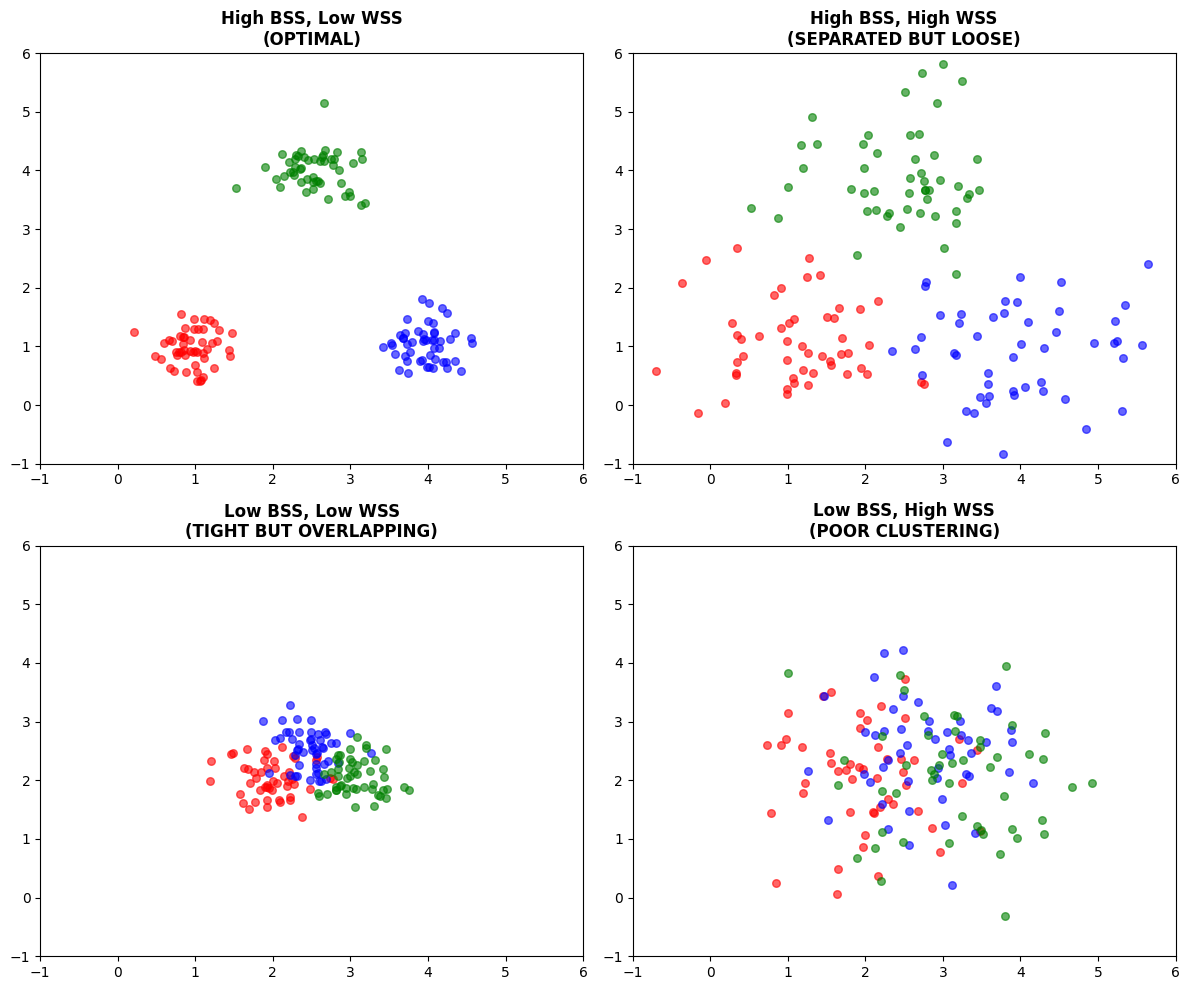

In [76]:
# Visualizing different clustering scenarios
np.random.seed(42)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top-Left: High BSS, Low WSS (OPTIMAL)
ax = axes[0, 0]
c1 = np.random.randn(50, 2) * 0.3 + [1, 1]
c2 = np.random.randn(50, 2) * 0.3 + [4, 1]
c3 = np.random.randn(50, 2) * 0.3 + [2.5, 4]
ax.scatter(c1[:, 0], c1[:, 1], c="red", s=30, alpha=0.6)
ax.scatter(c2[:, 0], c2[:, 1], c="blue", s=30, alpha=0.6)
ax.scatter(c3[:, 0], c3[:, 1], c="green", s=30, alpha=0.6)
ax.set_title("High BSS, Low WSS\n(OPTIMAL)", fontsize=12, fontweight="bold")
ax.set_xlim(-1, 6); ax.set_ylim(-1, 6)

# Top-Right: High BSS, High WSS (SEPARATED BUT LOOSE)
ax = axes[0, 1]
c1 = np.random.randn(50, 2) * 0.8 + [1, 1]
c2 = np.random.randn(50, 2) * 0.8 + [4, 1]
c3 = np.random.randn(50, 2) * 0.8 + [2.5, 4]
ax.scatter(c1[:, 0], c1[:, 1], c="red", s=30, alpha=0.6)
ax.scatter(c2[:, 0], c2[:, 1], c="blue", s=30, alpha=0.6)
ax.scatter(c3[:, 0], c3[:, 1], c="green", s=30, alpha=0.6)
ax.set_title("High BSS, High WSS\n(SEPARATED BUT LOOSE)", fontsize=12, fontweight="bold")
ax.set_xlim(-1, 6); ax.set_ylim(-1, 6)

# Bottom-Left: Low BSS, Low WSS (TIGHT BUT OVERLAPPING)
ax = axes[1, 0]
c1 = np.random.randn(50, 2) * 0.3 + [2, 2]
c2 = np.random.randn(50, 2) * 0.3 + [2.5, 2.5]
c3 = np.random.randn(50, 2) * 0.3 + [3, 2]
ax.scatter(c1[:, 0], c1[:, 1], c="red", s=30, alpha=0.6)
ax.scatter(c2[:, 0], c2[:, 1], c="blue", s=30, alpha=0.6)
ax.scatter(c3[:, 0], c3[:, 1], c="green", s=30, alpha=0.6)
ax.set_title("Low BSS, Low WSS\n(TIGHT BUT OVERLAPPING)", fontsize=12, fontweight="bold")
ax.set_xlim(-1, 6); ax.set_ylim(-1, 6)

# Bottom-Right: Low BSS, High WSS (POOR)
ax = axes[1, 1]
c1 = np.random.randn(50, 2) * 0.8 + [2, 2]
c2 = np.random.randn(50, 2) * 0.8 + [2.5, 2.5]
c3 = np.random.randn(50, 2) * 0.8 + [3, 2]
ax.scatter(c1[:, 0], c1[:, 1], c="red", s=30, alpha=0.6)
ax.scatter(c2[:, 0], c2[:, 1], c="blue", s=30, alpha=0.6)
ax.scatter(c3[:, 0], c3[:, 1], c="green", s=30, alpha=0.6)
ax.set_title("Low BSS, High WSS\n(POOR CLUSTERING)", fontsize=12, fontweight="bold")
ax.set_xlim(-1, 6); ax.set_ylim(-1, 6)

plt.tight_layout()
plt.show()

### How K-Means Works

K-Means is one of the most popular clustering algorithms. The goal is to partition $n$ data points into $K$ clusters, where each point belongs to the cluster with the nearest **mean** (center).

**The Algorithm:**

Given data points $x_1, \ldots, x_n \in \mathbb{R}^d$ and desired number of clusters $K$:

1. **Initialize**: Randomly select $K$ points as initial cluster centers $\mu_1, \ldots, \mu_K$

2. **Assignment**: Assign each point to the nearest center:
$$C_k = \{i : \|x_i - \mu_k\| \leq \|x_i - \mu_j\| \text{ for all } j\}$$

3. **Update**: Recalculate centers as the mean of assigned points:
$$\mu_k = \frac{1}{|C_k|} \sum_{i \in C_k} x_i$$

4. **Repeat** Steps 2-3 until convergence (labels stop changing)

**Connection to WSS:** The K-Means algorithm minimizes WSS! Each iteration reduces WSS until convergence.

---

**Problem 3: Implement Clustering Metrics**

Implement three functions to compute the clustering evaluation metrics:
- `tss(X)`: Total Sum of Squares
- `wss(X, labels)`: Within-Cluster Sum of Squares  
- `bss(X, labels)`: Between-Cluster Sum of Squares

where `X` is an $n \times d$ NumPy array and `labels` is a 1-D array of length $n$ with integer cluster labels.

In [77]:
# Generate demo data for testing
np.random.seed(503)
cluster_a = np.random.randn(30, 2) + np.array([3, 0])
cluster_b = np.random.randn(30, 2) + np.array([-2, 2])
cluster_c = np.random.randn(30, 2) + np.array([0, -3])

X_demo = np.vstack([cluster_a, cluster_b, cluster_c])
labels_demo = np.array([0] * 30 + [1] * 30 + [2] * 30)


def tss(data: np.ndarray) -> float:
    """
    Compute Total Sum of Squares.

    Parameters
    ----------
    data : np.ndarray
        Data matrix of shape (n, d).

    Returns
    -------
    float
        Total sum of squared distances from the grand mean.
    """
    grand_mean = data.mean(axis=0)
    return float(np.sum((data - grand_mean) ** 2))


def wss(data: np.ndarray, labels: np.ndarray) -> float:
    """
    Compute Within-Cluster Sum of Squares.

    Parameters
    ----------
    data : np.ndarray
        Data matrix of shape (n, d).
    labels : np.ndarray
        Cluster labels of shape (n,).

    Returns
    -------
    float
        Sum of squared distances from each point to its cluster mean.
    """
    total = 0.0
    for cluster_label in np.unique(labels):
        # Extract data points belonging to the current cluster
        cluster_data = data[labels == cluster_label]
        # Compute the mean of the current cluster
        cluster_mean = cluster_data.mean(axis=0)
        # Add the sum of squared distances from points in this cluster to their cluster mean
        total += np.sum((cluster_data - cluster_mean) ** 2)
    return float(total)


def bss(data: np.ndarray, labels: np.ndarray) -> float:
    """
    Compute Between-Cluster Sum of Squares.

    Parameters
    ----------
    data : np.ndarray
        Data matrix of shape (n, d).
    labels : np.ndarray
        Cluster labels of shape (n,).

    Returns
    -------
    float
        Weighted sum of squared distances from cluster means to the grand mean.
    """

    grand_mean = data.mean(axis=0)
    total = 0.0
    for cluster_label in np.unique(labels):
        cluster_data = data[labels == cluster_label]
        cluster_mean = cluster_data.mean(axis=0)
        # Add the weighted sum of squared distances from the cluster mean to the grand mean
        total += len(cluster_data) * np.sum((cluster_mean - grand_mean) ** 2)
    return float(total)

In [78]:
# Test assertions
tss_val = tss(X_demo)
wss_val = wss(X_demo, labels_demo)
bss_val = bss(X_demo, labels_demo)

print(f"TSS: {tss_val:.4f}")
print(f"WSS: {wss_val:.4f}")
print(f"BSS: {bss_val:.4f}")
print(f"WSS + BSS: {wss_val + bss_val:.4f}")

assert tss_val > 0, "TSS should be positive"
assert wss_val > 0, "WSS should be positive"
assert bss_val > 0, "BSS should be positive"
assert abs(wss_val + bss_val - tss_val) < 1e-7, "TSS should equal WSS + BSS"
print("All tests passed!")

TSS: 966.7841
WSS: 161.0902
BSS: 805.6939
WSS + BSS: 966.7841
All tests passed!


---

**Problem 4:** Implement K-Means from Scratch

Complete the K-Means implementation below. The initialization is provided. You need to implement:
1. The **assignment step**: compute distances and assign each point to the nearest center
2. The **update step**: recalculate centers as the mean of assigned points

Track `labels_history` and `centers_history` so we can visualize how the algorithm progresses.

**Use `random_state=503`.**

**Hint:** Use [`sklearn.metrics.pairwise_distances`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise_distances.html) to compute distances efficiently. This function returns a distance matrix where entry `[i, j]` is the distance between `data[i]` and `centers[j]`.

In [79]:
def kmeans_custom(
    data: np.ndarray,
    n_clusters: int,
    max_iter: int = 100,
    random_state: int = 503,
) -> tuple[np.ndarray, np.ndarray, list, list]:
    """
    Custom K-Means implementation with history tracking.

    Parameters
    ----------
    data : np.ndarray
        Data matrix of shape (n, d).
    n_clusters : int
        Number of clusters.
    max_iter : int
        Maximum number of iterations.
    random_state : int
        Random seed for reproducibility.

    Returns
    -------
    labels : np.ndarray
        Final cluster assignments of shape (n,).
    centers : np.ndarray
        Final cluster centers of shape (n_clusters, d).
    labels_history : list of np.ndarray
        Labels after each iteration (for visualization).
    centers_history : list of np.ndarray
        Centers after each iteration (for visualization).
    """
    np.random.seed(random_state)
    n, d = data.shape

    # Initialize centers by randomly selecting n_clusters data points
    indices = np.random.choice(n, n_clusters, replace=False)
    centers = data[indices].copy()

    labels_history = []
    centers_history = []
    labels = None

    for iteration in range(max_iter):
        # Compute distances from data points to cluster centers
        distances = pairwise_distances(data, centers)
        # Assign labels based on closest center
        new_labels = np.argmin(distances, axis=1)

        labels_history.append(new_labels.copy())
        centers_history.append(centers.copy())

        # Check for convergence (if labels do not change)
        if labels is not None and np.array_equal(new_labels, labels):
            labels = new_labels
            break

        labels = new_labels

        # Update cluster centers for each iteration 
        new_centers = np.zeros_like(centers)
        for cluster_index in range(n_clusters):
            cluster_points = data[labels == cluster_index]
            if len(cluster_points) == 0:
                new_centers[cluster_index] = data[np.random.choice(n)]
            else:
                new_centers[cluster_index] = cluster_points.mean(axis=0)

        centers = new_centers

    return labels, centers, labels_history, centers_history

Number of iterations: 13
Final labels shape: (150,)
Final centers shape: (3, 2)


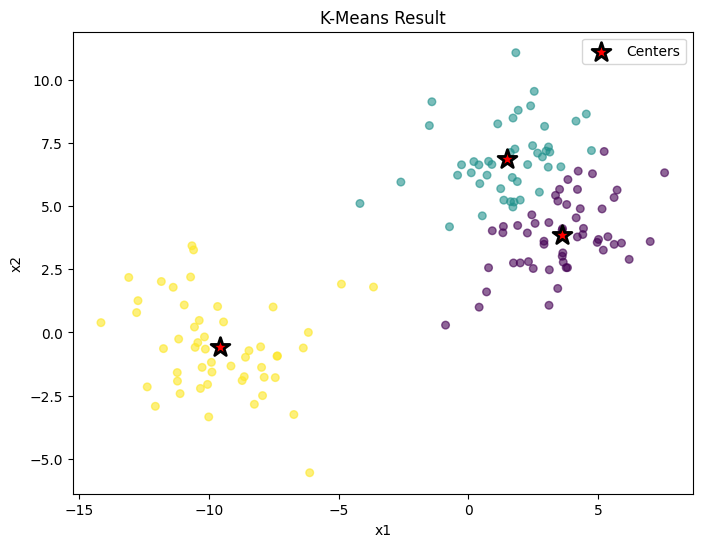

All tests passed!


In [80]:
# Test assertions
X_test, y_test = datasets.make_blobs(n_samples=150, centers=3, random_state=503, cluster_std=2.0)

labels_result, centers_result, labels_hist, centers_hist = kmeans_custom(
    X_test, n_clusters=3, random_state=503
)

print(f"Number of iterations: {len(labels_hist)}")
print(f"Final labels shape: {labels_result.shape}")
print(f"Final centers shape: {centers_result.shape}")

plt.figure(figsize=(8, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=labels_result, s=30, cmap="viridis", alpha=0.6)
plt.scatter(
    centers_result[:, 0], centers_result[:, 1],
    c="red", s=200, marker="*", edgecolors="black", linewidths=2, label="Centers",
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("K-Means Result")
plt.legend()
plt.show()

assert labels_result.shape == (150,), "Labels should have shape (150,)"
assert centers_result.shape == (3, 2), "Centers should have shape (3, 2)"
assert len(labels_hist) > 1, "Should have recorded multiple iterations"
print("All tests passed!")

---

**Problem 5:** Visualize K-Means Algorithm Progress

Complete the visualization function to see how K-Means evolves iteration by iteration. Create a subplot grid showing the cluster assignments at each iteration.

Use `random_state=503` when calling `kmeans_custom` in the test cell.

In [81]:
def visualize_kmeans_steps(
    data: np.ndarray,
    labels_history: list[np.ndarray],
    centers_history: list[np.ndarray],
) -> None:
    """
    Visualize K-Means algorithm progress across iterations.

    Parameters
    ----------
    data : np.ndarray
        Data matrix of shape (n, 2) - must be 2D for visualization.
    labels_history : list of np.ndarray
        Labels after each iteration.
    centers_history : list of np.ndarray
        Centers after each iteration.
    """
    n_iterations = len(labels_history)

    n_cols = min(4, n_iterations)
    n_rows = (n_iterations + n_cols - 1) // n_cols

    _fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    if n_iterations == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for idx in range(n_iterations):
        ax = axes[idx]
        labels = labels_history[idx]
        centers = centers_history[idx]
        # Solution: Use the provided labels and centers to visualize the clustering at each iteration
        ax.scatter(
            data[:, 0],
            data[:, 1],
            c=labels,
            cmap="viridis",
            s=30,
            alpha=0.7,
        )
        ax.scatter(
            centers[:, 0],
            centers[:, 1],
            c="red",
            s=160,
            marker="*",
            edgecolors="black",
            linewidths=1.0,
        )
        ax.set_title(f"Iteration {idx + 1}")
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")

    for idx in range(n_iterations, len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()

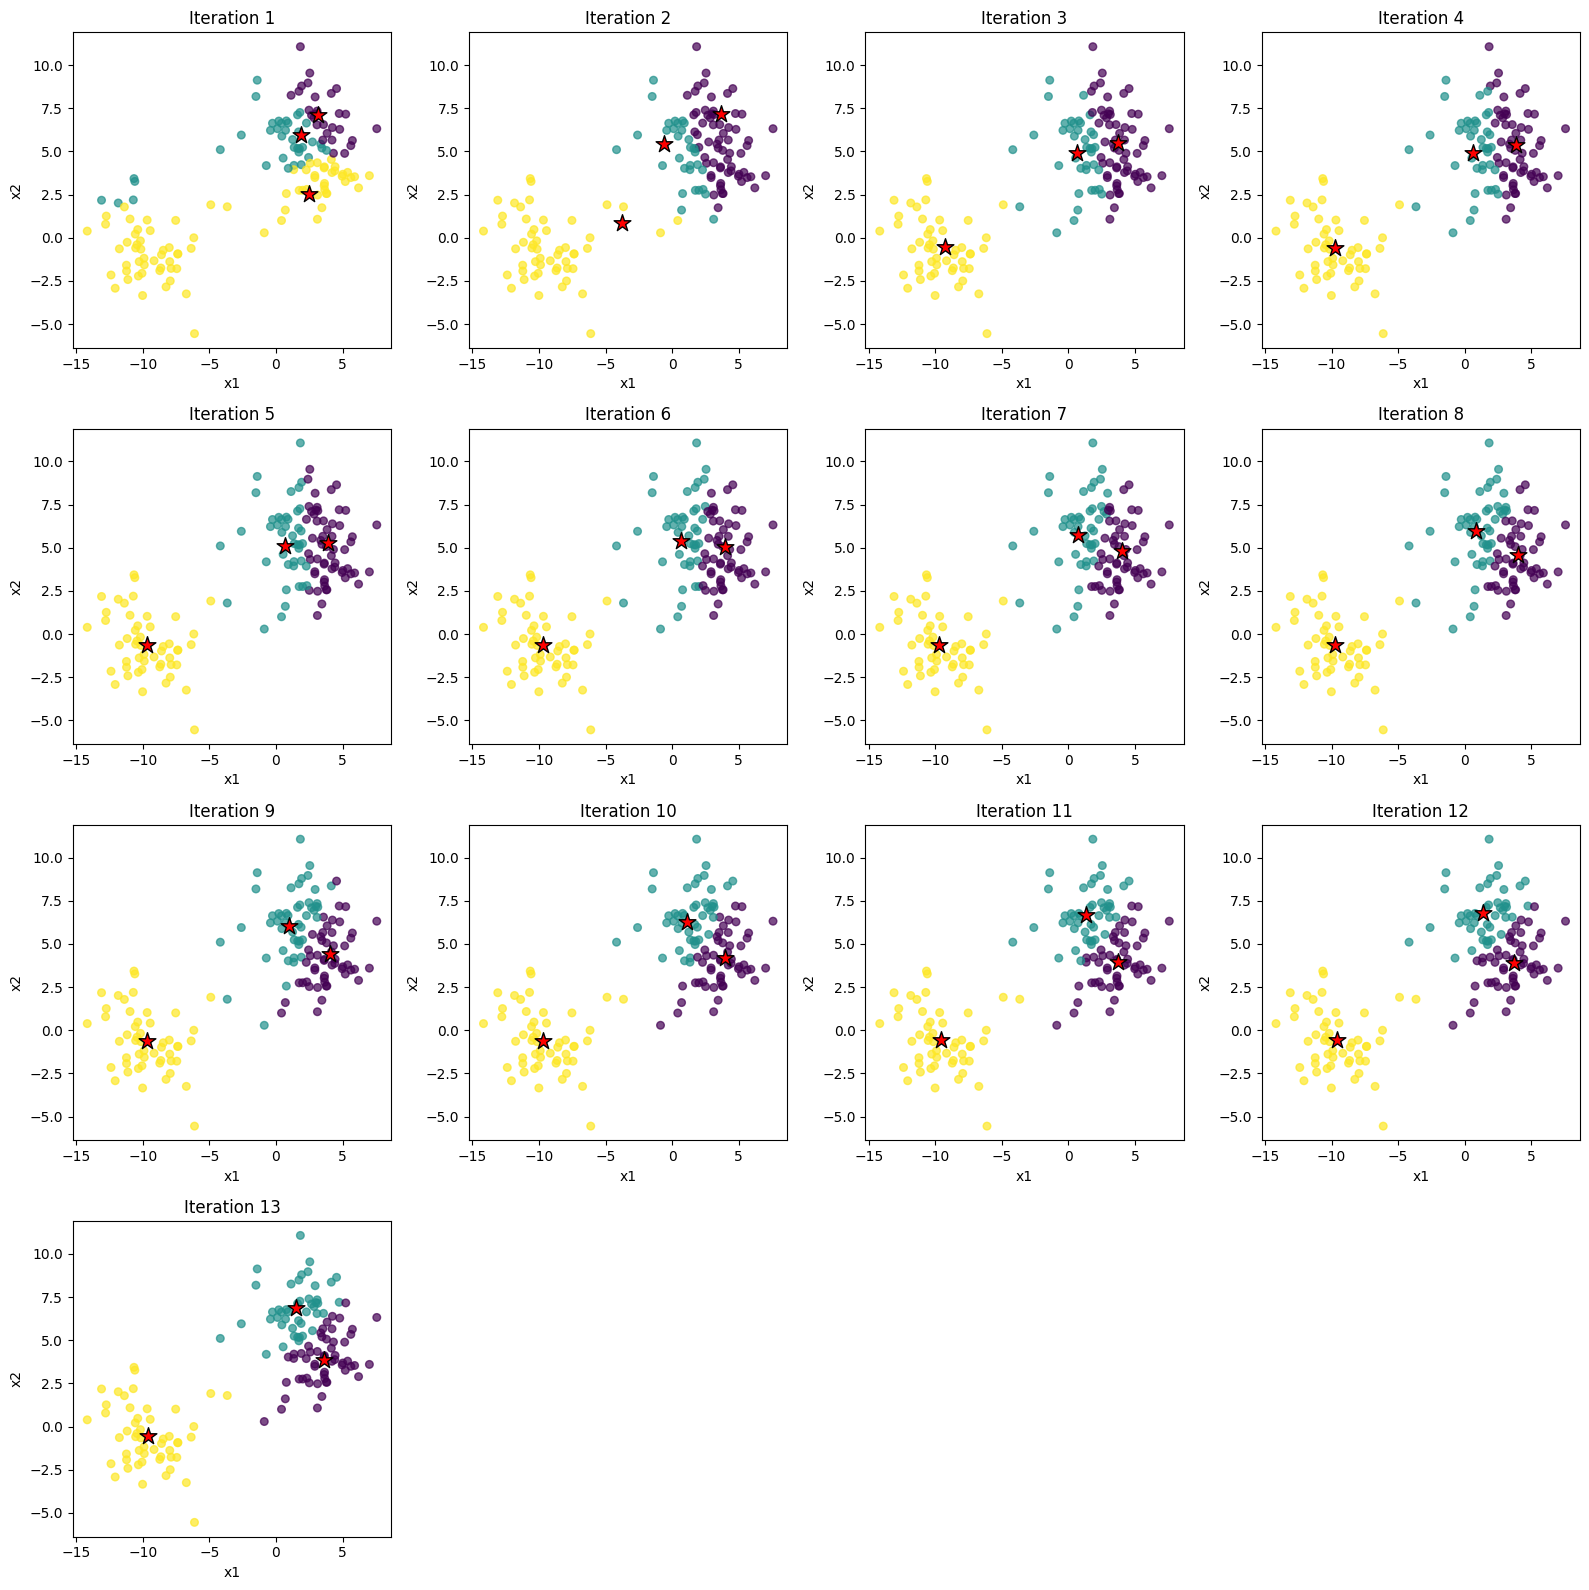

All tests passed!


In [82]:
labels, centers, labels_hist, centers_hist = kmeans_custom(
    X_test, n_clusters=3, random_state=503
)

visualize_kmeans_steps(X_test, labels_hist, centers_hist)

assert len(labels_hist) >= 1, "Should have at least 1 iteration recorded"
print("All tests passed!")

---

**Problem 6: K-Means Convergence**

Based on the visualizations above, which statement about K-Means with different random initializations is most accurate?

- **A.** K-Means always converges to the global optimum of WSS regardless of initialization.
- **B.** K-Means always produces the same final cluster assignments with different random seeds.
- **C.** Different random initializations can lead to different local minima; running multiple times and selecting the best result is a common strategy.
- **D.** The number of iterations to convergence is always the same regardless of initialization.

Set `answer_6 = "C"` (or whichever letter you choose).

In [83]:
answer_6 = "C"

In [84]:
# Test assertions
assert "answer_6" in dir(), "answer_6 should be defined"
assert answer_6 in ("A", "B", "C", "D"), "answer_6 should be one of A, B, C, D"
print("All tests passed!")

All tests passed!


## PCA + Clustering Combined

We have demonstrated how PCA works, but really, moving from 6 variables to 2 principal components is a trivial exercise. PCA is most effective when the data is truly of higher dimension. Using the synthetic low-rank data from Problem 1, we now compare clustering in the raw feature space versus the PCA-reduced space.

---

**Problem 7:** Clustering on Raw Data

Create a 2x3 subplot grid showing K-means clustering results with $K \in \{2, 3, 4, 5, 6, 7\}$ on the first two features of the synthetic data matrix `data_matrix` from Problem 1. Each subplot should show a scatter plot of the data colored by cluster assignment.

Use `random_state=503` and name the figure and axis object `fig, axes` respectively.

**Note:** Your plot must be organized as a subplot grid. Six separate plots arranged vertically will not receive credit.

In [85]:
data_matrix.shape

(250, 50)

In [86]:
# ?kmeans.fit_predict

In [87]:
# help(zip)

In [88]:
for ax, k in zip(flat_axes, ks):
    print(ax, k)

NameError: name 'flat_axes' is not defined

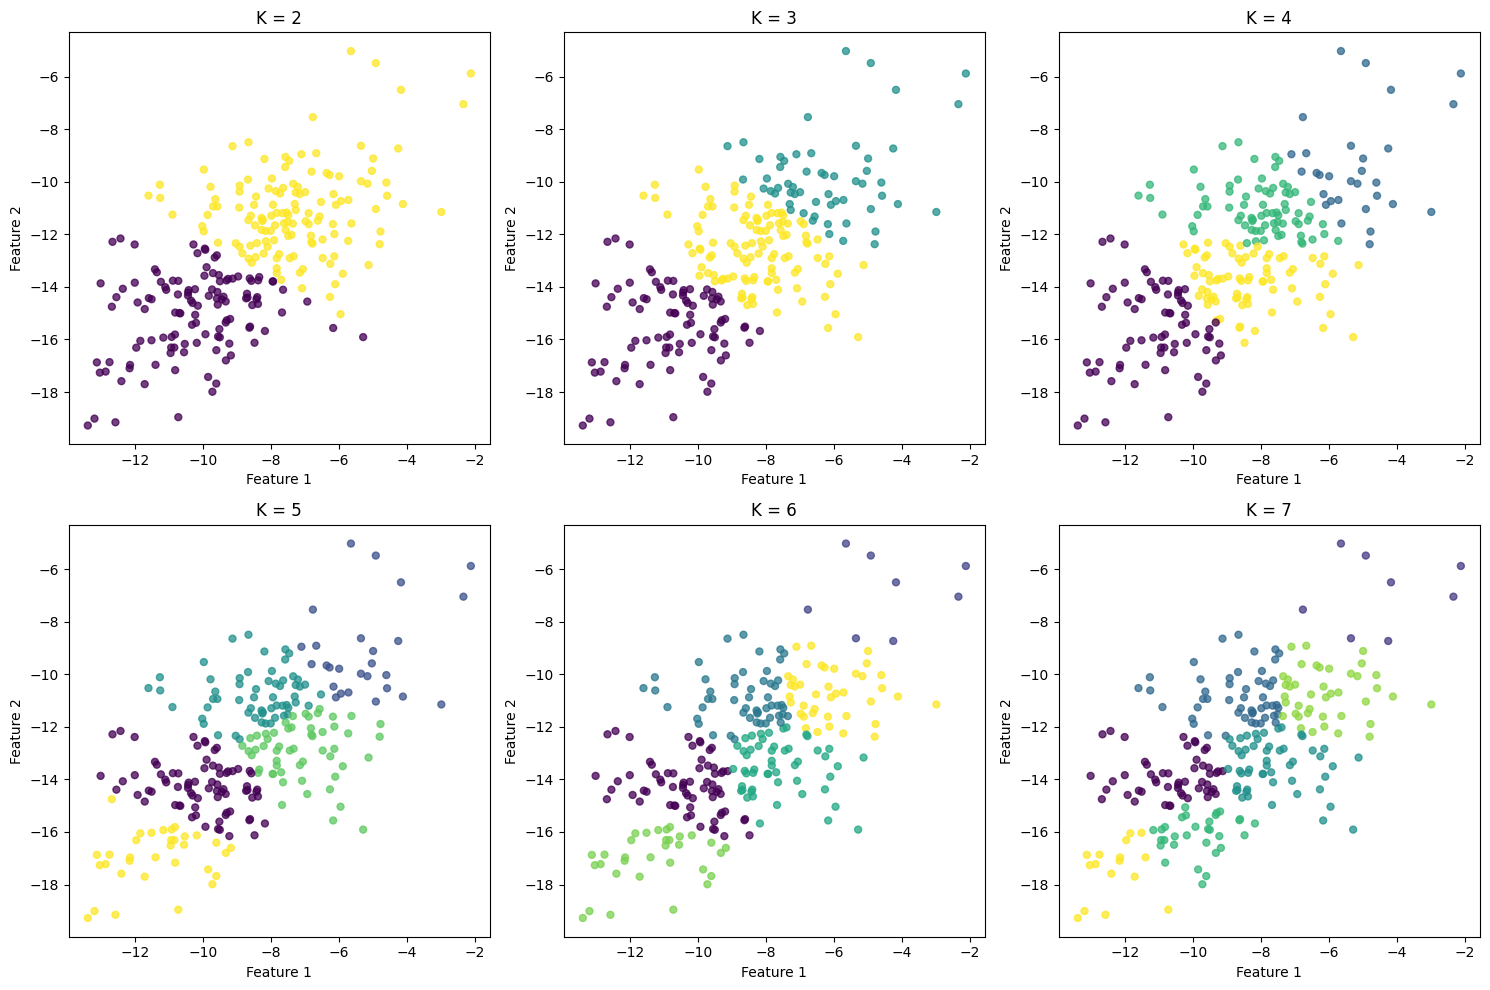

In [ ]:
X_raw = data_matrix[:, :2]
ks = [2, 3, 4, 5, 6, 7]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
flat_axes = axes.flatten()

for ax, k in zip(flat_axes, ks):
    kmeans = KMeans(n_clusters=k, random_state=503)
    # Solution: Fit KMeans and get cluster labels for visualization
    labels = kmeans.fit_predict(X_raw)

    ax.scatter(
        X_raw[:, 0],
        X_raw[:, 1],
        c=labels,
        cmap="viridis",
        s=25,
        alpha=0.75,
    )
    ax.set_title(f"K = {k}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

In [ ]:
# Test assertions
assert fig is not None, "Figure should be created"
assert axes.shape == (2, 3), f"Expected 2x3 subplot grid, got {axes.shape}"
print("All tests passed!")

All tests passed!


The 3 clusters we know to exist from construction do not look very separable. Perhaps using just 2 random features in the input space (which we know is a subset of features from a low-rank matrix) was not ideal. Instead, let us see if projecting to a lower-dimensional space (creating latent features) yields more separable clusters.

---

**Problem 8:** Clustering on PCA-Transformed Data

Now that we have established how many principal components to use (from Problem 2), visualize how many clusters are separable in the reduced PCA space. Create a 2x3 subplot grid showing K-means clustering results with $K \in \{2, 3, 4, 5, 6, 7\}$ on the PCA-transformed data using `n_pcs_chosen` components.

Store the PCA-transformed data in `pca_data`.

Use `random_state=503` and name the figure and axis object `fig_pca, axes_pca` respectively.

**Note:** Your plot must be organized as a subplot grid. Six separate plots arranged vertically will not receive credit.

In [ ]:
n_pcs_chosen

3

In [ ]:
pca_model

PCA(n_components=10, random_state=503)

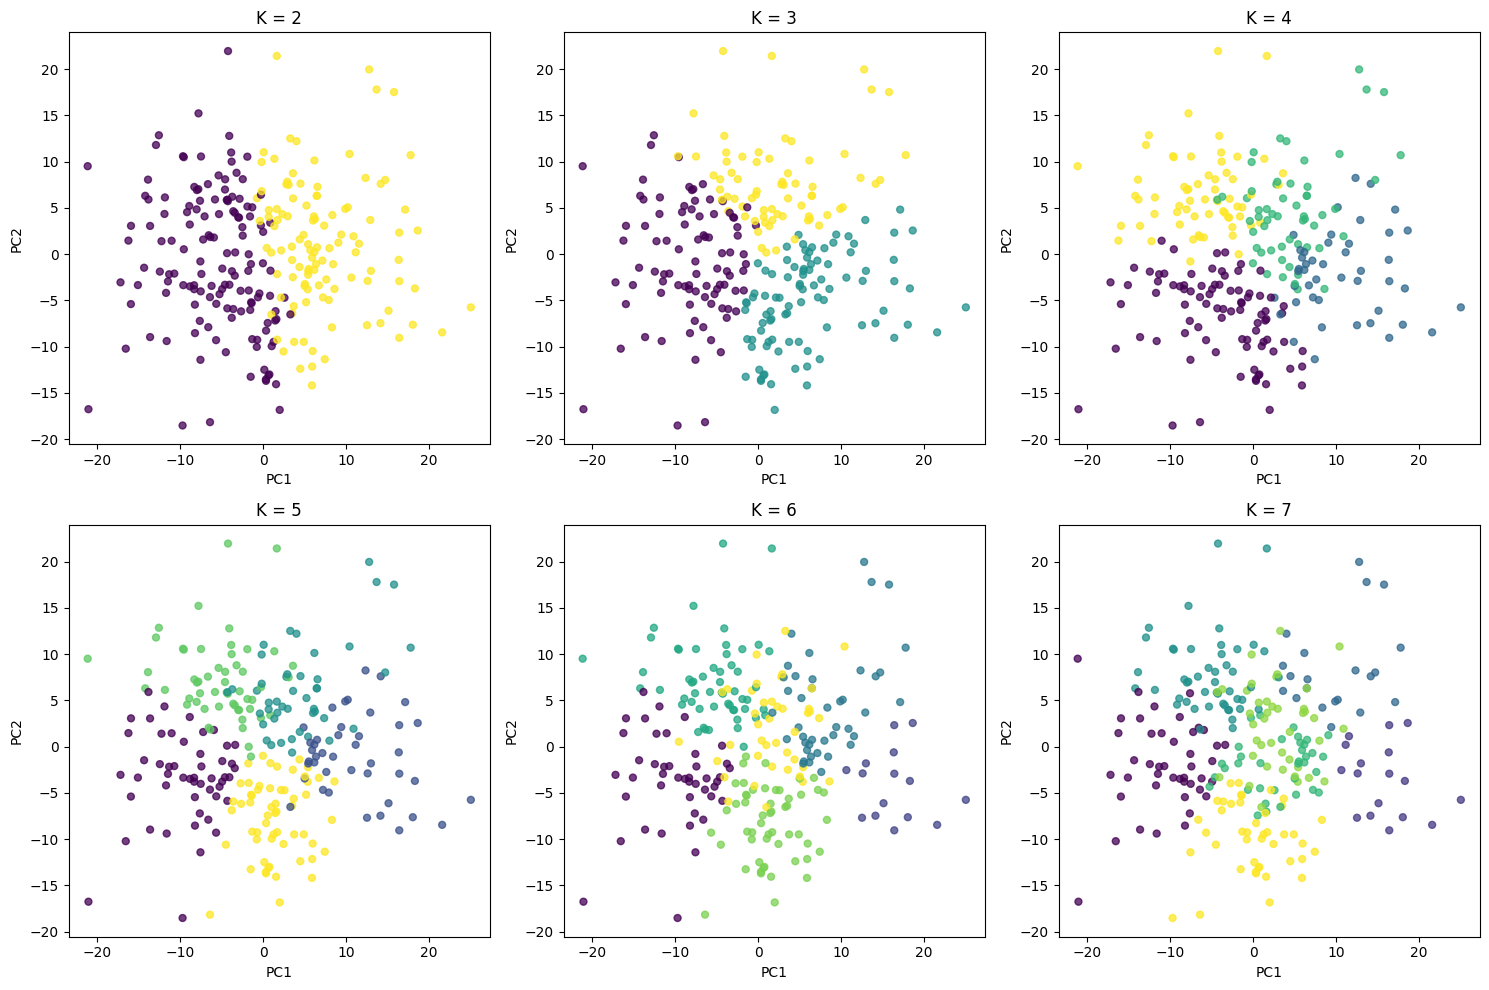

In [ ]:
pca_data = pca_model.transform(data_matrix)[:, :n_pcs_chosen]
ks = [2, 3, 4, 5, 6, 7]

fig_pca, axes_pca = plt.subplots(2, 3, figsize=(15, 10))
flat_axes = axes_pca.flatten()

for ax, k in zip(flat_axes, ks):
    kmeans = KMeans(n_clusters=k, random_state=503)
    labels = kmeans.fit_predict(pca_data)

    ax.scatter(
        pca_data[:, 0],
        pca_data[:, 1],
        c=labels,
        cmap="viridis",
        s=25,
        alpha=0.75,
    )
    ax.set_title(f"K = {k}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

In [ ]:
# Test assertions
assert fig_pca is not None, "Figure should be created"
assert axes_pca.shape == (2, 3), f"Expected 2x3 subplot grid, got {axes_pca.shape}"
assert pca_data.shape[1] == n_pcs_chosen, f"PCA should reduce to {n_pcs_chosen} components"
print("All tests passed!")

All tests passed!


---

**Problem 9: Interpreting PCA Space**

Comparing your plots from Problems 7 and 8, which best explains why K-Means clusters are more visually separable in PCA space than in the original raw feature space?

- **A.** PCA adds new features that create artificial separation between groups.
- **B.** PCA clusters the data directly, so cluster structure is always more visible after PCA.
- **C.** PCA projects data onto directions of maximum variance, concentrating signal while discarding noisy dimensions.
- **D.** PCA increases the dimensionality of the data, providing more room for clusters to separate.

Set `answer_9 = "C"` (or whichever letter you choose).

In [ ]:
answer_9 = "C"

In [ ]:
# Test assertions
assert "answer_9" in dir(), "answer_9 should be defined"
assert answer_9 in ("A", "B", "C", "D"), "answer_9 should be one of A, B, C, D"
print("All tests passed!")

All tests passed!


## Working with Gene Expression Data

Gene expression data is a good example of real data that typically requires dimensionality reduction. Some datasets have tens of thousands of genes. We will work with a dataset that has been reduced for us thanks to the [scanpy](https://scanpy.readthedocs.io/en/stable/generated/scanpy.datasets.pbmc68k_reduced.html) library.

We have included the relevant code needed to load the dataset into the notebook. The data is an [annotated data matrix](https://anndata.readthedocs.io/en/stable/). It is a class that handles data organization, usually for single-cell data.

Here is a quick summary of each anndata component (you will not need to use them all for this lab):

- **X**: The primary two-dimensional data matrix (e.g., gene expression) where rows usually correspond to cells and columns to features (genes).
- **obs**: A DataFrame storing per-observation (often per-cell) annotations such as cluster labels or metadata.
- **var**: A DataFrame storing per-variable (often per-gene) annotations like gene symbols or feature quality metrics.
- **uns**: A dictionary-like structure for unstructured annotations, typically holding things like color schemes, parameter settings, or additional metadata.
- **obsm**: A dictionary of matrices aligned with observations (cells), commonly used for embeddings (e.g., PCA, UMAP coordinates).
- **varm**: A dictionary of matrices aligned with variables (genes), often used for storing feature loadings in dimensionality reduction.
- **layers**: A dictionary of additional data layers (e.g., raw counts, imputed data) that share the same dimensionality as X but may differ in values.
- **raw**: An optional structure holding the unmodified or "raw" version of the data matrix (plus corresponding var), often used to preserve counts before normalization or filtering.

In [65]:
# JUST RUN, DO NOT EDIT
adata = sc.datasets.pbmc68k_reduced()
print(adata)

AnnData object with n_obs × n_vars = 700 × 765
    obs: 'bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain'
    var: 'n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


---

**Problem 10:** Working with Scanpy Datasets

(a) Using the data matrix `X` and the PCA matrix `X_pca`, determine the number of observations and features in each dataset. Fill in the correct values for `num_cells_x`, `num_genes_x`, `num_cells_pca`, and `num_pcs`.

(b) Store the number of unique cell types in `n_cell_types`.

In [68]:
gene_expression_pca = adata.obsm["X_pca"]

num_cells_x, num_genes_x = adata.X.shape
num_cells_pca, num_pcs = gene_expression_pca.shape
n_cell_types = adata.obs["bulk_labels"].nunique()

print(f"adata.X shape: {adata.X.shape}")
print(f"adata.obsm['X_pca'] shape: {gene_expression_pca.shape}")
print(f"Number of cell types: {n_cell_types}")

adata.X shape: (700, 765)
adata.obsm['X_pca'] shape: (700, 50)
Number of cell types: 10


In [67]:
# Test assertions
assert num_cells_x == 700, f"Expected 700 cells in X, got {num_cells_x}"
assert num_genes_x == 765, f"Expected 765 genes in X, got {num_genes_x}"
assert num_cells_pca == 700, f"Expected 700 cells in X_pca, got {num_cells_pca}"
assert num_pcs == 50, f"Expected 50 PCs in X_pca, got {num_pcs}"
assert isinstance(n_cell_types, (int, np.integer)), "n_cell_types should be an integer"
print("All tests passed!")

All tests passed!


---

**Problem 11a:** K-Means Clustering on Raw Gene Expression Data

Perform K-means clustering on the entire gene expression dataset (`adata.X`). Use $K \in \{5, 10, 15\}$. Store the cluster assignments in the per-observation annotations (`obs`) with keys `kmeans5_ALL`, `kmeans10_ALL`, and `kmeans15_ALL`. The $K=5$ example is provided for you.

Use `random_state=503`.

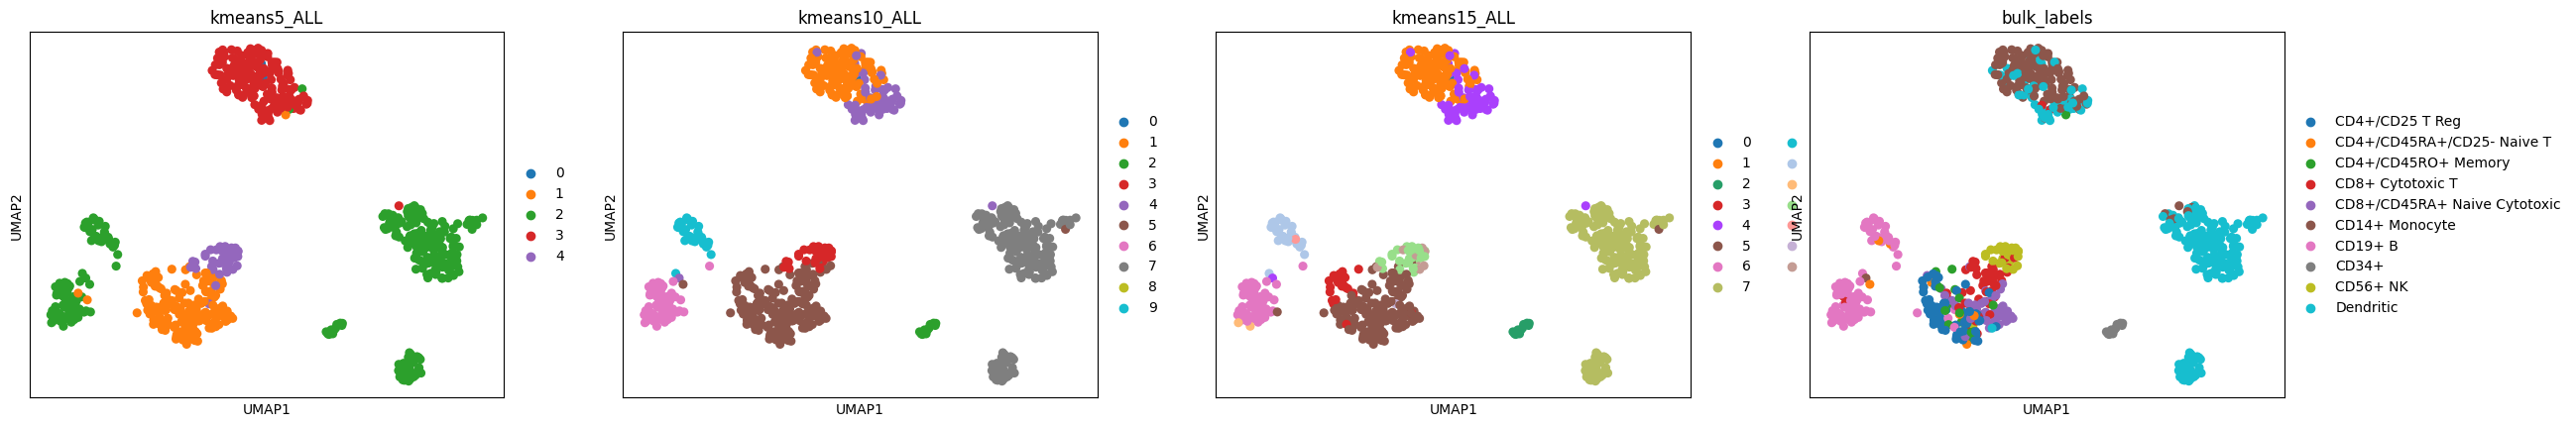

In [69]:
gene_data = adata.X

# kmeans with k=5 (provided example)
kmeans = KMeans(n_clusters=5, random_state=503).fit(gene_data)
adata.obs["kmeans5_ALL"] = kmeans.labels_.astype(str)

# kmeans with k=10
kmeans = KMeans(n_clusters=10, random_state=503).fit(gene_data)
adata.obs["kmeans10_ALL"] = kmeans.labels_.astype(str)

# kmeans with k=15
kmeans = KMeans(n_clusters=15, random_state=503).fit(gene_data)
adata.obs["kmeans15_ALL"] = kmeans.labels_.astype(str)

# Visualize clusters in UMAP space
sc.pl.umap(adata, color=["kmeans5_ALL", "kmeans10_ALL", "kmeans15_ALL", "bulk_labels"])

In [70]:
# Test assertions
assert "kmeans5_ALL" in adata.obs.columns, "kmeans5_ALL should be in obs"
assert "kmeans10_ALL" in adata.obs.columns, "kmeans10_ALL should be in obs"
assert "kmeans15_ALL" in adata.obs.columns, "kmeans15_ALL should be in obs"
print("All tests passed!")

All tests passed!


---

**Problem 11b:** K-Means Clustering on PCA-Transformed Gene Data

Now perform the same K-means clustering ($K \in \{5, 10, 15\}$) but using the principal components as clustering input. Store results with keys `kmeans5_PC`, `kmeans10_PC`, and `kmeans15_PC`.

Use `random_state=503`.

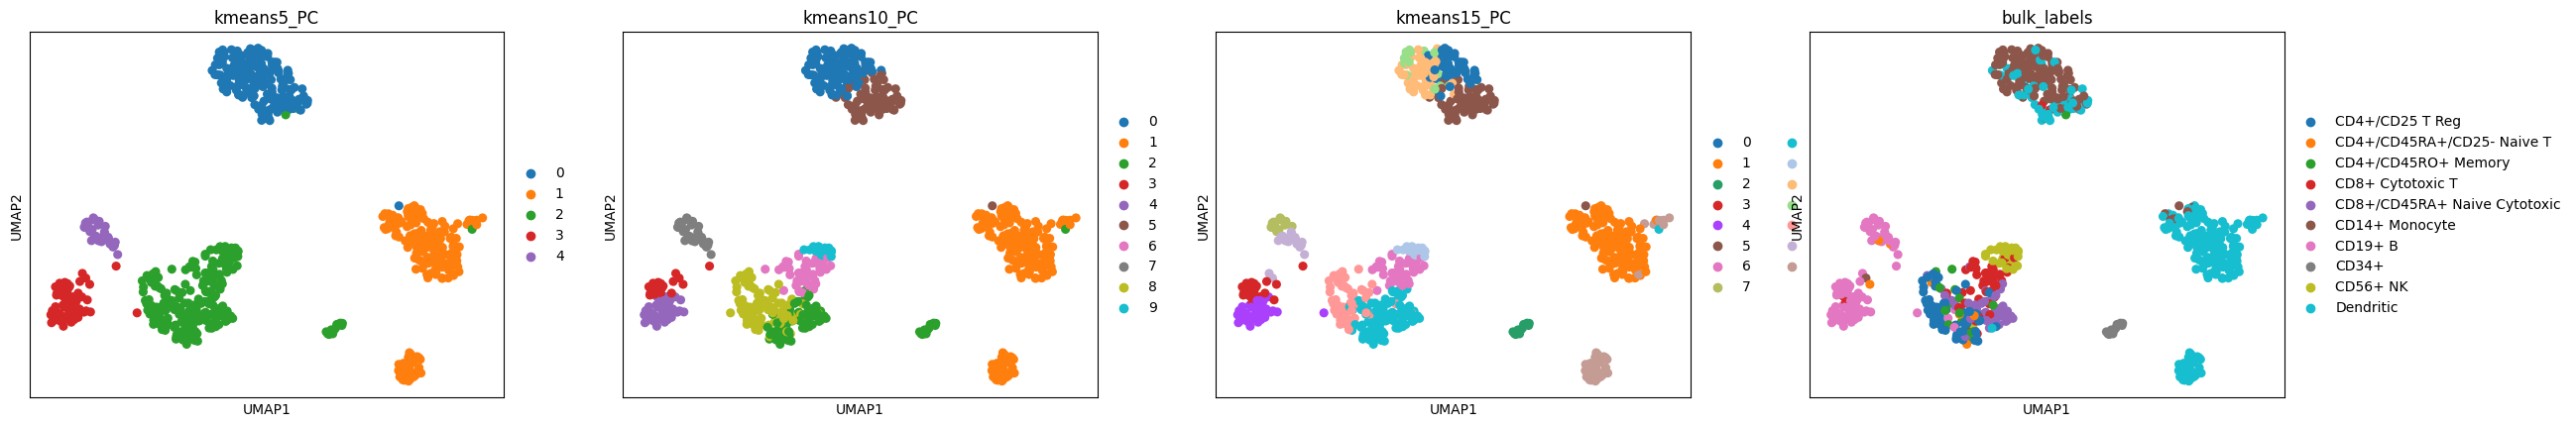

In [71]:
# Extract PCA coordinates
gene_pca_data = adata.obsm["X_pca"]

# kmeans with k=5
kmeans = KMeans(n_clusters=5, random_state=503).fit(gene_pca_data)
adata.obs["kmeans5_PC"] = kmeans.labels_.astype(str)

# kmeans with k=10
kmeans = KMeans(n_clusters=10, random_state=503).fit(gene_pca_data)
adata.obs["kmeans10_PC"] = kmeans.labels_.astype(str)

# kmeans with k=15
kmeans = KMeans(n_clusters=15, random_state=503).fit(gene_pca_data)
adata.obs["kmeans15_PC"] = kmeans.labels_.astype(str)

# Visualize clusters in UMAP space
sc.pl.umap(adata, color=["kmeans5_PC", "kmeans10_PC", "kmeans15_PC", "bulk_labels"])

In [72]:
# Test assertions
assert "kmeans5_PC" in adata.obs.columns, "kmeans5_PC should be in obs"
assert "kmeans10_PC" in adata.obs.columns, "kmeans10_PC should be in obs"
assert "kmeans15_PC" in adata.obs.columns, "kmeans15_PC should be in obs"
print("All tests passed!")

All tests passed!


---

**Problem 12a:** Hierarchical Clustering on Raw Gene Expression Data

Perform agglomerative (hierarchical) clustering on the entire gene expression dataset (`gene_data`). Use `n_clusters` $\in \{5, 10, 15\}$ with Euclidean distance and Ward linkage. Store the cluster assignments in obs with keys `hclust_5_ALL`, `hclust_10_ALL`, and `hclust_15_ALL`. The $n=5$ example is provided for you.

See [`AgglomerativeClustering`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html) for documentation.

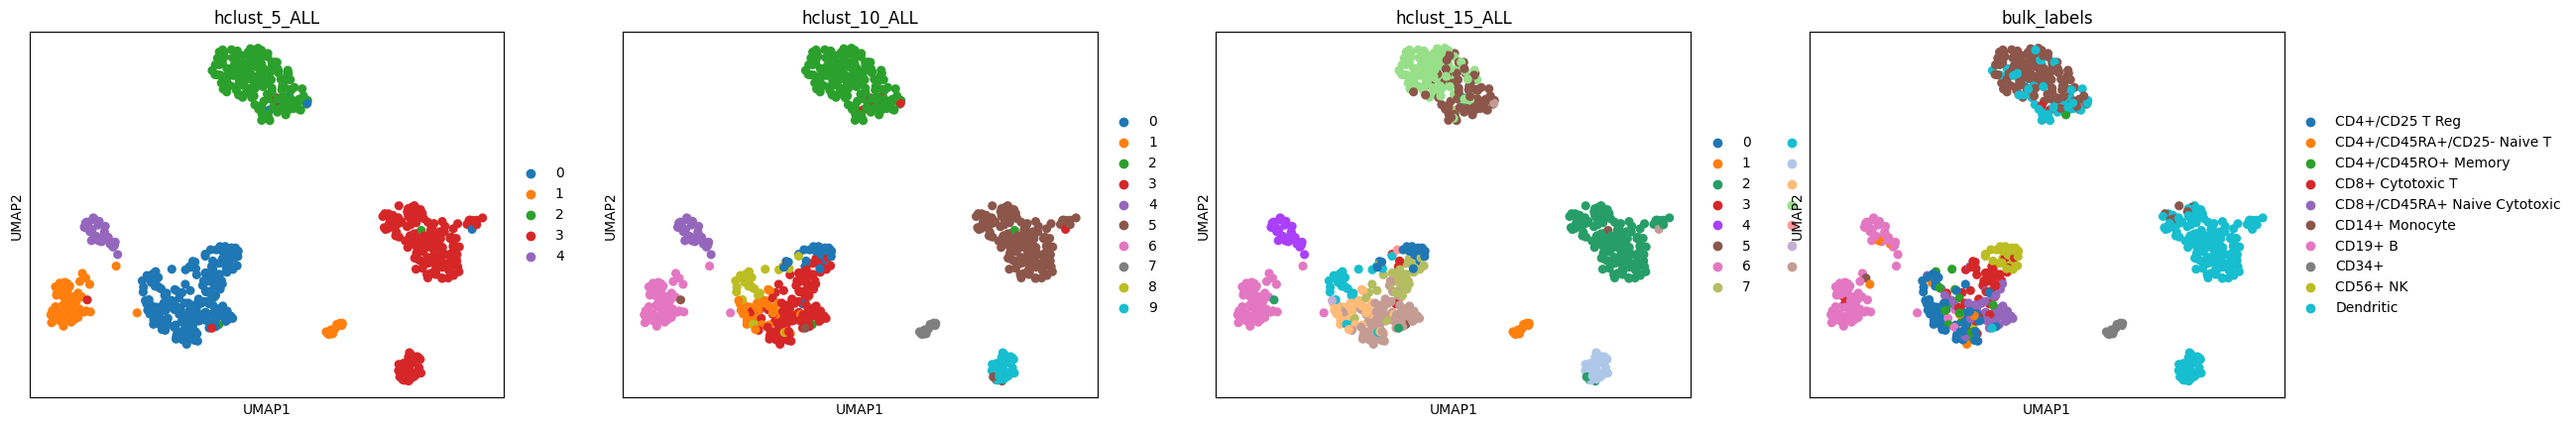

In [73]:
# Hierarchical clustering with n_clusters=5 (provided example)
cluster = AgglomerativeClustering(n_clusters=5, metric="euclidean", linkage="ward")
adata.obs["hclust_5_ALL"] = cluster.fit_predict(gene_data).astype(str)

# Hierarchical clustering with n_clusters=10
cluster = AgglomerativeClustering(n_clusters=10, metric="euclidean", linkage="ward")
adata.obs["hclust_10_ALL"] = cluster.fit_predict(gene_data).astype(str)

# Hierarchical clustering with n_clusters=15
cluster = AgglomerativeClustering(n_clusters=15, metric="euclidean", linkage="ward")
adata.obs["hclust_15_ALL"] = cluster.fit_predict(gene_data).astype(str)

# Visualize clusters in UMAP space
sc.pl.umap(adata, color=["hclust_5_ALL", "hclust_10_ALL", "hclust_15_ALL", "bulk_labels"])

In [74]:
# Test assertions
assert "hclust_5_ALL" in adata.obs.columns, "hclust_5_ALL should be in obs"
assert "hclust_10_ALL" in adata.obs.columns, "hclust_10_ALL should be in obs"
assert "hclust_15_ALL" in adata.obs.columns, "hclust_15_ALL should be in obs"
print("All tests passed!")

All tests passed!


---

**Problem 12b:** Hierarchical Clustering on PCA-Transformed Gene Data

Now perform the same hierarchical clustering (`n_clusters` $\in \{5, 10, 15\}$) but using the principal components as clustering input. Store results with keys `hclust_5_PC`, `hclust_10_PC`, and `hclust_15_PC`.

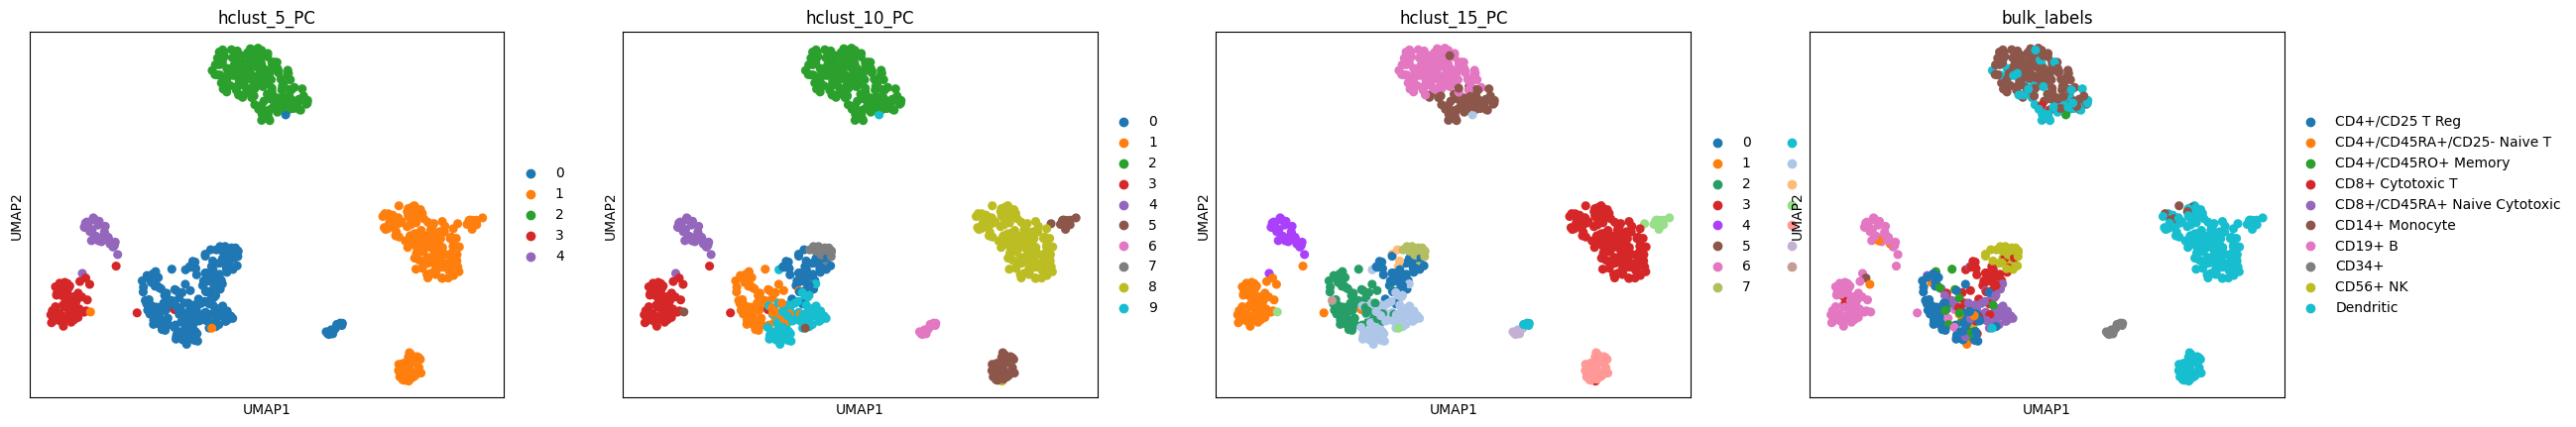

In [75]:
gene_pca_data = adata.obsm["X_pca"]

# Hierarchical clustering with n_clusters=5
cluster = AgglomerativeClustering(n_clusters=5, metric="euclidean", linkage="ward")
adata.obs["hclust_5_PC"] = cluster.fit_predict(gene_pca_data).astype(str)

# Hierarchical clustering with n_clusters=10
cluster = AgglomerativeClustering(n_clusters=10, metric="euclidean", linkage="ward")
adata.obs["hclust_10_PC"] = cluster.fit_predict(gene_pca_data).astype(str)

# Hierarchical clustering with n_clusters=15
cluster = AgglomerativeClustering(n_clusters=15, metric="euclidean", linkage="ward")
adata.obs["hclust_15_PC"] = cluster.fit_predict(gene_pca_data).astype(str)

# Visualize clusters in UMAP space
sc.pl.umap(adata, color=["hclust_5_PC", "hclust_10_PC", "hclust_15_PC", "bulk_labels"])

In [76]:
# Test assertions
assert "hclust_5_PC" in adata.obs.columns, "hclust_5_PC should be in obs"
assert "hclust_10_PC" in adata.obs.columns, "hclust_10_PC should be in obs"
assert "hclust_15_PC" in adata.obs.columns, "hclust_15_PC should be in obs"
print("All tests passed!")

All tests passed!


---

**Problem 13:** Evaluating Cluster Assignments

We have run all the clustering algorithms, but just looking at the cluster assignments is not a great way to evaluate them. One cluster evaluation metric is the [adjusted Rand index (ARI)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html). You do not need to fully understand the formula; just know that scores closer to 1 mean nearly identical clusters while values 0 or below represent random or discordant clusters.

(a) Use [`adjusted_rand_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html) to evaluate all previous clusterings against the true `bulk_labels`. Store the highest ARI value in `max_ari`.

In [80]:
all_clusters = [
    "kmeans5_ALL", "kmeans10_ALL", "kmeans15_ALL",
    "kmeans5_PC", "kmeans10_PC", "kmeans15_PC",
    "hclust_5_ALL", "hclust_10_ALL", "hclust_15_ALL",
    "hclust_5_PC", "hclust_10_PC", "hclust_15_PC",
]

true_labels = adata.obs["bulk_labels"]

ari_scores = []
for cluster_key in all_clusters:
    ari = adjusted_rand_score(true_labels, adata.obs[cluster_key])
    ari_scores.append(ari)

max_ari = max(ari_scores)
best_cluster = all_clusters[int(np.argmax(ari_scores))]
print(f"Best clustering: {best_cluster} with ARI = {max_ari:.4f}")

Best clustering: kmeans10_PC with ARI = 0.5685


In [81]:
# Test assertions
assert max_ari > 0, "max_ari should be positive"
print("All tests passed!")

All tests passed!
